In [8]:
from typing import TypedDict

from langgraph.graph import START, END, StateGraph


class GraphState(TypedDict):
    message: str
    response: str


def process_message(state: GraphState):
    return {
        "response": f"Received: {state['message']}"
    }


graph_builder = StateGraph(GraphState)

graph_builder.add_node(
    "process_message",
    process_message
)

graph_builder.add_edge(
    START,
    "process_message"
)

graph_builder.add_edge(
    "process_message",
    END
)

graph = graph_builder.compile()


result = graph.invoke(
    {
        "message": "Analyze this customer",
        "response": ""
    }
)

print(result)

{'message': 'Analyze this customer', 'response': 'Received: Analyze this customer'}


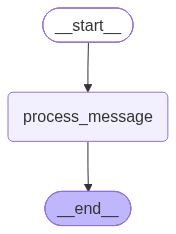

In [9]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
import os
from typing import TypedDict

from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import START, END, StateGraph


GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")


class GraphState(TypedDict):
    message: str
    response: str


llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    google_api_key=GOOGLE_API_KEY,
    # temperature=0   # Deprecated for Gemini 3.x models
)


def call_llm(state: GraphState):
    response = llm.invoke(
        state["message"]
    )

    return {
        "response": response.content
    }


graph_builder = StateGraph(GraphState)

graph_builder.add_node(
    "call_llm",
    call_llm
)

graph_builder.add_edge(
    START,
    "call_llm"
)

graph_builder.add_edge(
    "call_llm",
    END
)

graph = graph_builder.compile()


result = graph.invoke(
    {
        "message": "Explain customer churn in one sentence.",
        "response": ""
    }
)

print(result["response"])

ModuleNotFoundError: No module named 'schemas'